# SFM Example

This is the canonical structure-from-motion (SFM) example in GTSAM, and it pulls together ideas used elsewhere in this notebook series: projection factors (`VisualISAMExample`), the `DoglegOptimizer` (`DogLegOptimizerExample`, `SelfCalibrationExample`), and marginal-covariance visualization (`OdometryExample`) -- now applied all at once to a full 3D bundle-adjustment problem.

Unlike `VisualISAMExample`, which fed observations to an incremental solver one pose at a time, this notebook builds the *entire* factor graph up front and solves it in a single batch optimization with `DoglegOptimizer`. The scene is the same 10-meter landmark cube with 8 cameras circling it, this time with a known, fixed calibration.

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/SFMExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import gtsam
from gtsam import symbol_shorthand

L = symbol_shorthand.L
X = symbol_shorthand.X

from gtsam.examples import SFMdata
from gtsam.utils import plot

from gtsam import (Cal3_S2, DoglegOptimizer, GenericProjectionFactorCal3_S2,
                   Marginals, NonlinearFactorGraph, PinholeCameraCal3_S2,
                   PriorFactorPoint3, PriorFactorPose3, Values)

## 1. Scene and camera setup

Ground-truth landmarks and poses come from the shared `SFMdata` helper module, same as `VisualISAMExample`. Here calibration `K` is known and fixed -- there's no self-calibration in this notebook.

In [3]:
# Define the camera calibration parameters
K = Cal3_S2(50.0, 50.0, 0.0, 50.0, 50.0)

# Define the camera observation noise model
measurement_noise = gtsam.noiseModel.Isotropic.Sigma(2, 1.0)  # one pixel in u and v

# Create the set of ground-truth landmarks
points = SFMdata.createPoints()

# Create the set of ground-truth poses
poses = SFMdata.createPoses()

## 2. Build the factor graph

A prior on pose `x0` indirectly fixes the origin of the whole reconstruction. Then, for every pose/landmark pair, we project the ground-truth landmark through the camera to get a simulated pixel measurement, and add a `GenericProjectionFactorCal3_S2` -- the same factor type used in `VisualISAMExample`, but here every observation goes into one graph, built entirely before optimization starts.

In [4]:
# Create a factor graph
graph = NonlinearFactorGraph()

# Add a prior on pose x1. This indirectly specifies where the origin is.
# 0.3 rad std on roll,pitch,yaw and 0.1m on x,y,z
pose_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.3, 0.3, 0.3, 0.1, 0.1, 0.1]))
factor = PriorFactorPose3(X(0), poses[0], pose_noise)
graph.push_back(factor)

# Simulated measurements from each camera pose, adding them to the factor graph
for i, pose in enumerate(poses):
    camera = PinholeCameraCal3_S2(pose, K)
    for j, point in enumerate(points):
        measurement = camera.project(point)
        factor = GenericProjectionFactorCal3_S2(measurement, measurement_noise, X(i), L(j), K)
        graph.push_back(factor)

## 3. Fix the scale ambiguity

SFM alone can't distinguish a small scene photographed up close from a large scene photographed from far away -- the pixel measurements look identical either way. This is the same kind of ambiguity that makes self-calibration hard in `SelfCalibrationExample`, but here it's about *scale* rather than focal length. A single prior on landmark `l0` pins the distance between the first camera and the first landmark, and every other landmark position is interpreted relative to that scale.

In [5]:
point_noise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)
factor = PriorFactorPoint3(L(0), points[0], point_noise)
graph.push_back(factor)
print(graph)

NonlinearFactorGraph: size: 66

Factor 0: PriorFactor on x0
  prior mean:  R: [
	6.12323e-17, -6.12323e-17, -1;
	1, 3.7494e-33, 6.12323e-17;
	-0, -1, 6.12323e-17
]
t: 30  0  0
  noise model: diagonal sigmas [0.3; 0.3; 0.3; 0.1; 0.1; 0.1];

Factor 1: GenericProjectionFactor, z = [
	75;
	25
]
  keys = { x0 l0 }
  noise model: unit (2) 

Factor 2: GenericProjectionFactor, z = [
	62.5;
	37.5
]
  keys = { x0 l1 }
  noise model: unit (2) 

Factor 3: GenericProjectionFactor, z = [
	37.5;
	37.5
]
  keys = { x0 l2 }
  noise model: unit (2) 

Factor 4: GenericProjectionFactor, z = [
	25;
	25
]
  keys = { x0 l3 }
  noise model: unit (2) 

Factor 5: GenericProjectionFactor, z = [
	75;
	75
]
  keys = { x0 l4 }
  noise model: unit (2) 

Factor 6: GenericProjectionFactor, z = [
	62.5;
	62.5
]
  keys = { x0 l5 }
  noise model: unit (2) 

Factor 7: GenericProjectionFactor, z = [
	37.5;
	62.5
]
  keys = { x0 l6 }
  noise model: unit (2) 

Factor 8: GenericProjectionFactor, z = [
	25;
	75
]
  keys = { x0

## 4. Initial estimate

Unlike `VisualISAMExample` and `SelfCalibrationExample`, which perturb the ground truth by a single fixed offset, this one draws independent random Gaussian noise for every pose and landmark (`numpy`'s `default_rng`, with no fixed seed) -- so the exact initial values, and the optimizer's exact path, will differ each time this notebook runs. The qualitative outcome won't: Dogleg should still converge to the true reconstruction.

In [6]:
# Create the data structure to hold the initial estimate to the solution
# Intentionally initialize the variables off from the ground truth
initial_estimate = Values()
rng = np.random.default_rng()
for i, pose in enumerate(poses):
    transformed_pose = pose.retract(0.1 * rng.standard_normal(6).reshape(6, 1))
    initial_estimate.insert(X(i), transformed_pose)
for j, point in enumerate(points):
    transformed_point = point + 0.1 * rng.standard_normal(3)
    initial_estimate.insert(L(j), transformed_point)
print(initial_estimate)

Values with 16 values:
Value l0: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10.0869602;
	9.96091842;
	10.1211717
]

Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10.1295932;
	9.97613053;
	9.94859734
]

Value l2: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-9.96875639;
	-9.89461118;
	10.0942002
]

Value l3: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.93882244;
	-9.98982859;
	10.0902699
]

Value l4: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10.1333898;
	10.0027059;
	-9.91343828
]

Value l5: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10.079499;
	10.0780763;
	-9.9280996
]

Value l6: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-9.97038322;
	-10.0010005;
	-9.83838347
]

Value l7: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10.0938091;
	-10.0271396;
	-9.92943968
]

Value x0: (gtsam::Pose3)
R: [
	0.00131051623, -0.0734329544, -0.997299295;
	0.999993616, -0.00321905278, 0.00155108143;
	-0.00332425956, -0.997294961, 0.073428267
]
t:     29.974475 -0.0698303209  0.0430406692

Valu

## 5. Optimize with Dogleg

`setVerbosity("TERMINATION")` makes the optimizer print why and when it stopped. We also print the graph error before and after optimization, to see how far the solution moved.

In [7]:
params = gtsam.DoglegParams()
params.setVerbosity("TERMINATION")
optimizer = DoglegOptimizer(graph, initial_estimate, params)
print("Optimizing:")
result = optimizer.optimize()
print(result)
print("initial error = {}".format(graph.error(initial_estimate)))
print("final error = {}".format(graph.error(result)))

Optimizing:
Values with 16 values:
Value l0: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10;
	10;
	10
]

Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10;
	9.99999999997;
	9.99999999995
]

Value l2: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10;
	-10;
	9.99999999998
]

Value l3: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.99999999997;
	-10;
	9.99999999998
]

Value l4: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10;
	9.99999999999;
	-10
]

Value l5: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-9.99999999999;
	9.99999999995;
	-10
]

Value l6: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10;
	-10;
	-10
]

Value l7: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.99999999998;
	-10;
	-10
]

Value x0: (gtsam::Pose3)
R: [
	-1.84188244614e-13, 7.46359676361e-13, -1;
	1, -2.81088838409e-13, -1.84188226178e-13;
	-2.81088872272e-13, -1, -7.46360412373e-13
]
t:                 30 -1.61865886803e-16 -3.28505942941e-15

Value x1: (gtsam::Pose3)
R: [
	-0.707106781184, -3.17775310427e-12, -

## 6. Visualize with uncertainty

As in `OdometryExample`, we compute `Marginals` on the batch result and plot each landmark and camera pose together with its covariance ellipse -- only now in 3D, showing the recovered cube of landmarks and the recovered camera trajectory around it side by side.

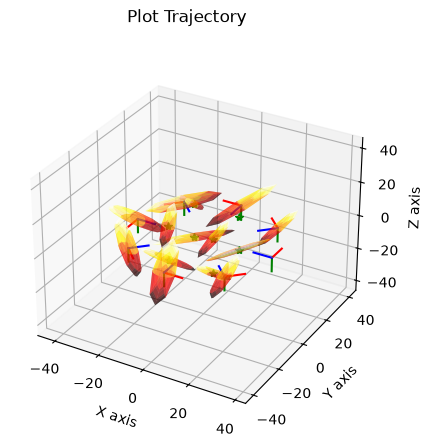

In [8]:
marginals = Marginals(graph, result)
plot.plot_3d_points(1, result, marginals=marginals)
plot.plot_trajectory(1, result, marginals=marginals, scale=8)
plot.set_axes_equal(1)
plt.show()

The final error should be many orders of magnitude smaller than the initial error, and the plot above should show landmarks close to a cube and poses close to a circular orbit -- confirming that Dogleg recovered the true reconstruction from a randomly perturbed start, using nothing but pixel observations, a single pose prior to fix the origin, and a single landmark prior to fix the scale.